# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves.

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

<img src="https://github.com/yandexdataschool/deep_vision_and_graphics/blob/fall22/week02-convnets/cifar10.jpg?raw=1" style="width:80%">

In [2]:
# **IMPORTANT** when running in colab, un-comment this
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week03_convnets/cifar.py

--2025-09-29 15:56:20--  https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week03_convnets/cifar.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2396 (2.3K) [text/plain]
Saving to: ‘cifar.py’

cifar.py            100%[===================>]   2.34K  --.-KB/s    in 0s      

2025-09-29 15:56:20 (25.8 MB/s) - ‘cifar.py’ saved [2396/2396]



In [3]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

Dataset not found. Downloading...
(40000, 3, 32, 32) (40000,)


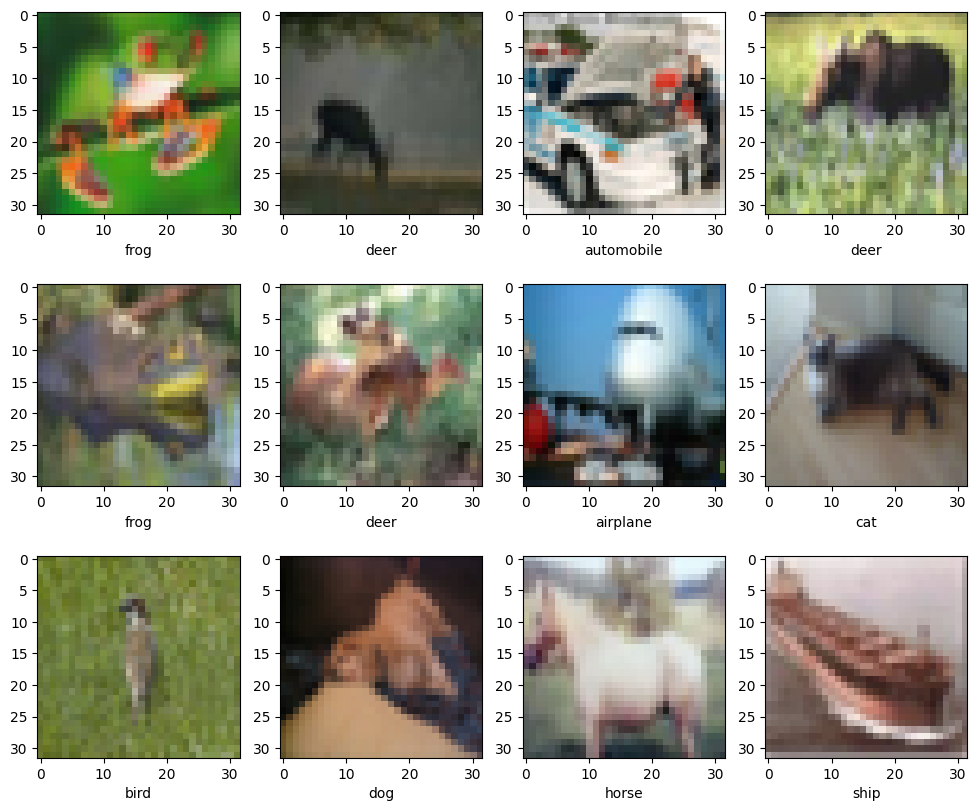

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

Let's start with a dense network for our baseline, then gradually improve it.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

model = nn.Sequential(
    nn.Flatten(),  # reshape images to vectors; if you have conv / pool layers, they go BEFORE flatten
    nn.Linear(3 * 32 * 32, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # logits for 10 classes. No softmax - this is intentional
)

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [6]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [7]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(2.2907, grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [8]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [9]:
import time
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            y_pred = logits.argmax(-1).detach().numpy()
            val_accuracy.append(np.mean(y_batch == y_pred))

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 100 took 2.023s
  training loss (in-iteration): 	2.032135
  validation accuracy: 			34.00 %
Epoch 2 of 100 took 2.009s
  training loss (in-iteration): 	1.854179
  validation accuracy: 			36.65 %
Epoch 3 of 100 took 2.520s
  training loss (in-iteration): 	1.780074
  validation accuracy: 			39.03 %
Epoch 4 of 100 took 2.296s
  training loss (in-iteration): 	1.727893
  validation accuracy: 			40.68 %
Epoch 5 of 100 took 2.050s
  training loss (in-iteration): 	1.683071
  validation accuracy: 			42.40 %
Epoch 6 of 100 took 2.006s
  training loss (in-iteration): 	1.646869
  validation accuracy: 			42.39 %
Epoch 7 of 100 took 1.990s
  training loss (in-iteration): 	1.618246
  validation accuracy: 			43.41 %
Epoch 8 of 100 took 1.970s
  training loss (in-iteration): 	1.592389
  validation accuracy: 			43.91 %
Epoch 9 of 100 took 2.814s
  training loss (in-iteration): 	1.570411
  validation accuracy: 			45.19 %
Epoch 10 of 100 took 1.997s
  training loss (in-iteration): 	1.550697
  v

KeyboardInterrupt: 

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [10]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		50.86 %
Achievement unlocked: 60lvl Warlock!


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


model = nn.Sequential()


model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3))
model.add_module('relu1', nn.ReLU())


model.add_module('pool1', nn.MaxPool2d(kernel_size=2))


model.add_module('flatten', nn.Flatten())


with torch.no_grad():
    dummy_out = model(torch.zeros(1, 3, 32, 32))
    flat_dim = dummy_out.shape[1]
print("Flattened dimension =", flat_dim)


model.add_module('fc1', nn.Linear(flat_dim, 100))
model.add_module('relu2', nn.ReLU())


model.add_module('dropout', nn.Dropout(p=0.1))


model.add_module('fc2', nn.Linear(100, 10))


def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

print(compute_loss(X_train[:5], y_train[:5]))

opt = torch.optim.Adam(model.parameters())


Flattened dimension = 2250
tensor(2.3025, grad_fn=<MeanBackward0>)


In [12]:
import time
train_loss = []
val_accuracy = []

num_epochs = 20
batch_size = 50

for epoch in range(num_epochs):
    start_time = time.time()
    model.train(True)


    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())


    model.train(False)
    with torch.no_grad():
        for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            y_pred = logits.argmax(-1).detach().numpy()
            val_accuracy.append(np.mean(y_batch == y_pred))

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"took {time.time()-start_time:.2f}s | "
          f"train loss: {np.mean(train_loss[-len(X_train)//batch_size:]):.4f} | "
          f"val acc: {np.mean(val_accuracy[-len(X_val)//batch_size:])*100:.2f}%")


model.train(False)
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.argmax(-1).detach().numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("\nFinal results:")
print(f"  test accuracy: {test_accuracy*100:.2f}%")


Epoch 1/20 took 11.26s | train loss: 1.6763 | val acc: 48.28%
Epoch 2/20 took 11.88s | train loss: 1.3939 | val acc: 54.35%
Epoch 3/20 took 11.74s | train loss: 1.2738 | val acc: 55.69%
Epoch 4/20 took 11.76s | train loss: 1.1983 | val acc: 57.84%
Epoch 5/20 took 11.67s | train loss: 1.1342 | val acc: 59.03%
Epoch 6/20 took 11.56s | train loss: 1.0893 | val acc: 58.71%
Epoch 7/20 took 11.54s | train loss: 1.0400 | val acc: 60.25%
Epoch 8/20 took 11.58s | train loss: 1.0011 | val acc: 60.30%
Epoch 9/20 took 11.66s | train loss: 0.9655 | val acc: 60.87%
Epoch 10/20 took 11.64s | train loss: 0.9319 | val acc: 60.80%
Epoch 11/20 took 11.64s | train loss: 0.8955 | val acc: 61.08%
Epoch 12/20 took 11.73s | train loss: 0.8669 | val acc: 60.88%
Epoch 13/20 took 11.67s | train loss: 0.8395 | val acc: 61.67%
Epoch 14/20 took 11.64s | train loss: 0.8132 | val acc: 62.05%
Epoch 15/20 took 11.67s | train loss: 0.7861 | val acc: 61.53%
Epoch 16/20 took 11.68s | train loss: 0.7601 | val acc: 60.45%
E

```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F


model = nn.Sequential()


model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3))
model.add_module('bn1', nn.BatchNorm2d(10))
model.add_module('relu1', nn.ReLU())


model.add_module('pool1', nn.MaxPool2d(kernel_size=2))


model.add_module('flatten', nn.Flatten())


with torch.no_grad():
    dummy_out = model(torch.zeros(1, 3, 32, 32))
    flat_dim = dummy_out.shape[1]
print("Flattened dimension =", flat_dim)


model.add_module('fc1', nn.Linear(flat_dim, 100))
model.add_module('bn2', nn.BatchNorm1d(100))
model.add_module('relu2', nn.ReLU())


model.add_module('dropout', nn.Dropout(p=0.1))


model.add_module('fc2', nn.Linear(100, 10))


def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()


opt = torch.optim.Adam(model.parameters())


Flattened dimension = 2250


In [14]:
import time
import matplotlib.pyplot as plt

def train_model(model, opt, num_epochs=20, batch_size=50):
    train_loss = []
    val_accuracy = []
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        start_time = time.time()
        model.train(True)


        batch_losses = []
        for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
            loss = compute_loss(X_batch, y_batch)
            loss.backward()
            opt.step()
            opt.zero_grad()
            batch_losses.append(loss.item())
            train_loss.append(loss.item())


        avg_train_loss = np.mean(batch_losses)


        model.train(False)
        batch_acc = []
        with torch.no_grad():
            for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
                logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
                y_pred = logits.argmax(-1).detach().numpy()
                batch_acc.append(np.mean(y_batch == y_pred))

        avg_val_acc = np.mean(batch_acc)

        history["train_loss"].append(avg_train_loss)
        history["val_acc"].append(avg_val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} "
              f"took {time.time()-start_time:.2f}s | "
              f"train loss: {avg_train_loss:.4f} | "
              f"val acc: {avg_val_acc*100:.2f}%")

    return history

In [15]:
def evaluate_on_test(model):
    model.train(False)
    test_batch_acc = []
    with torch.no_grad():
        for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
            y_pred = logits.argmax(-1).detach().numpy()
            test_batch_acc.append(np.mean(y_batch == y_pred))
    test_accuracy = np.mean(test_batch_acc)

    print("\nFinal results:")
    print(f"  test accuracy: {test_accuracy*100:.2f}%")

    if test_accuracy * 100 > 95:
        print("Double-check, then consider applying for NeurIPS :)")
    elif test_accuracy * 100 > 90:
        print("U'r freakin' amazin'!")
    elif test_accuracy * 100 > 80:
        print("Achievement unlocked: 110lvl Warlock!")
    elif test_accuracy * 100 > 70:
        print("Achievement unlocked: 80lvl Warlock!")
    elif test_accuracy * 100 > 60:
        print("Achievement unlocked: 70lvl Warlock!")
    elif test_accuracy * 100 > 50:
        print("Achievement unlocked: 60lvl Warlock!")
    else:
        print("We need more magic! Follow instructions below :)")


Epoch 1/20 took 13.56s | train loss: 1.3996 | val acc: 58.33%
Epoch 2/20 took 13.41s | train loss: 1.1157 | val acc: 61.16%
Epoch 3/20 took 13.41s | train loss: 0.9855 | val acc: 59.30%
Epoch 4/20 took 13.32s | train loss: 0.9045 | val acc: 62.89%
Epoch 5/20 took 13.39s | train loss: 0.8292 | val acc: 64.52%
Epoch 6/20 took 13.55s | train loss: 0.7616 | val acc: 63.66%
Epoch 7/20 took 13.37s | train loss: 0.6947 | val acc: 63.72%
Epoch 8/20 took 13.42s | train loss: 0.6525 | val acc: 60.24%
Epoch 9/20 took 13.39s | train loss: 0.6068 | val acc: 62.45%
Epoch 10/20 took 13.60s | train loss: 0.5636 | val acc: 62.80%
Epoch 11/20 took 13.78s | train loss: 0.5249 | val acc: 62.35%
Epoch 12/20 took 13.44s | train loss: 0.4905 | val acc: 61.87%
Epoch 13/20 took 13.36s | train loss: 0.4681 | val acc: 62.53%
Epoch 14/20 took 13.49s | train loss: 0.4367 | val acc: 61.47%
Epoch 15/20 took 13.65s | train loss: 0.4145 | val acc: 63.10%
Epoch 16/20 took 13.81s | train loss: 0.3879 | val acc: 61.91%
E

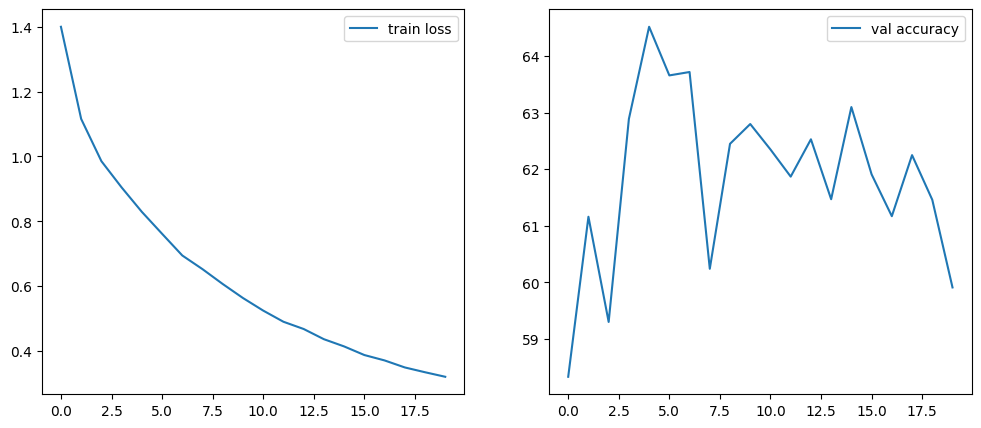


Final results:
  test accuracy: 59.17%
Achievement unlocked: 60lvl Warlock!


In [16]:
history = train_model(model, opt, num_epochs=20, batch_size=50)


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(np.array(history["val_acc"])*100, label="val accuracy")
plt.legend()
plt.show()


evaluate_on_test(model)



```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [ ]:
# from torchvision import transforms
# means = np.array((0.4914, 0.4822, 0.4465))  # statistics from dataset documentation
# stds = np.array((0.2023, 0.1994, 0.2010))

# transform_augment = transforms.Compose([
#     transforms.RandomCrop(32, padding=4),
#     transforms.RandomRotation([-30, 30]),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize(means, stds),
# ])

In [ ]:
# from torchvision.datasets import CIFAR10
# train_loader = CIFAR10("./cifar_data/", train=True, transform=transform_augment)

# train_dataloader = torch.utils.data.DataLoader(
#     train_loader,  batch_size=32, shuffle=True, num_workers=1)

In [ ]:

# for (x_batch, y_batch) in train_dataloader:

#     print('X:', type(x_batch), x_batch.shape)
#     print('y:', type(y_batch), y_batch.shape)

#     for i, img in enumerate(x_batch.numpy()[:8]):
#         plt.subplot(2, 4, i+1)
#         plt.imshow(img.transpose([1,2,0]) * stds + means )


#     raise NotImplementedError("Plese use this code in your training loop")
#     # TODO use this in your training loop

When testing, we don't need random crops, just normalize with same statistics.

In [ ]:
# transform_test = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(means, stds),
# ])

# test_loader = <YOUR CODE>

In [17]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
import torch


means = (0.4914, 0.4822, 0.4465)
stds  = (0.2023, 0.1994, 0.2010)

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])


train_dataset = CIFAR10("./cifar_data/", train=True, transform=transform_augment, download=True)
test_dataset  = CIFAR10("./cifar_data/", train=False, transform=transform_test, download=True)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=1)
test_dataloader  = torch.utils.data.DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=1)

In [18]:
def train_with_loader(model, opt, train_dataloader, test_dataloader, num_epochs=20):
    history = {"train_loss": [], "val_acc": []}
    for epoch in range(num_epochs):
        model.train(True)
        batch_losses = []
        for x_batch, y_batch in train_dataloader:
            logits = model(x_batch)
            loss = F.cross_entropy(logits, y_batch)
            loss.backward()
            opt.step()
            opt.zero_grad()
            batch_losses.append(loss.item())

        avg_train_loss = np.mean(batch_losses)


        model.train(False)
        correct, total = 0, 0
        with torch.no_grad():
            for x_batch, y_batch in test_dataloader:
                logits = model(x_batch)
                y_pred = logits.argmax(-1)
                correct += (y_pred == y_batch).sum().item()
                total   += y_batch.size(0)

        val_acc = correct / total
        history["train_loss"].append(avg_train_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"train loss: {avg_train_loss:.4f} | "
              f"val acc: {val_acc*100:.2f}%")

    return history


Epoch 1/20 | train loss: 1.8474 | val acc: 58.66%
Epoch 2/20 | train loss: 1.5063 | val acc: 59.31%
Epoch 3/20 | train loss: 1.4393 | val acc: 60.21%
Epoch 4/20 | train loss: 1.4037 | val acc: 60.93%
Epoch 5/20 | train loss: 1.3829 | val acc: 60.87%
Epoch 6/20 | train loss: 1.3543 | val acc: 62.19%
Epoch 7/20 | train loss: 1.3449 | val acc: 62.06%
Epoch 8/20 | train loss: 1.3299 | val acc: 61.84%
Epoch 9/20 | train loss: 1.3198 | val acc: 63.06%
Epoch 10/20 | train loss: 1.3115 | val acc: 63.18%
Epoch 11/20 | train loss: 1.3038 | val acc: 62.99%
Epoch 12/20 | train loss: 1.2960 | val acc: 62.87%
Epoch 13/20 | train loss: 1.2857 | val acc: 63.59%
Epoch 14/20 | train loss: 1.2776 | val acc: 64.12%
Epoch 15/20 | train loss: 1.2831 | val acc: 64.01%
Epoch 16/20 | train loss: 1.2770 | val acc: 63.21%
Epoch 17/20 | train loss: 1.2732 | val acc: 63.98%
Epoch 18/20 | train loss: 1.2667 | val acc: 63.43%
Epoch 19/20 | train loss: 1.2644 | val acc: 63.64%
Epoch 20/20 | train loss: 1.2587 | val a

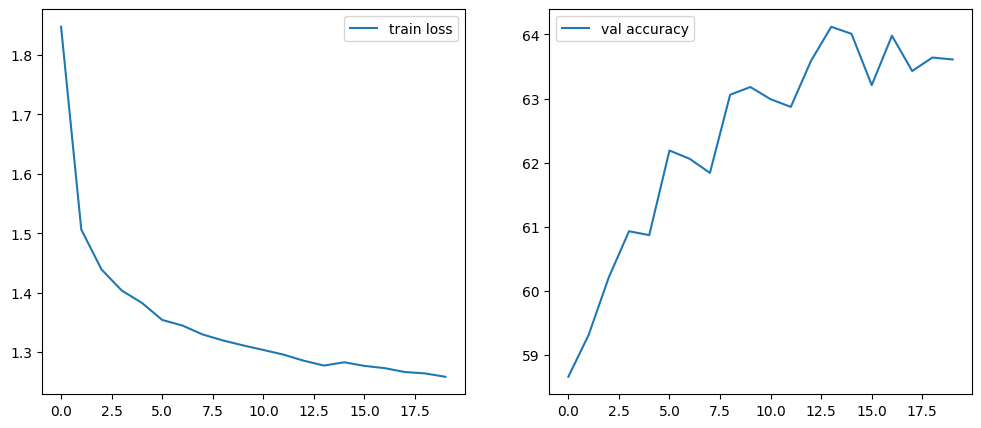


Final Test Accuracy: 63.61%


0.6361

In [19]:
def evaluate_final(model, test_dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_batch, y_batch in test_dataloader:
            logits = model(x_batch)
            y_pred = logits.argmax(-1)
            correct += (y_pred == y_batch).sum().item()
            total   += y_batch.size(0)
    acc = correct / total
    print(f"\nFinal Test Accuracy: {acc*100:.2f}%")
    return acc


history = train_with_loader(model, opt, train_dataloader, test_dataloader, num_epochs=20)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(np.array(history["val_acc"])*100, label="val accuracy")
plt.legend()
plt.show()

evaluate_final(model, test_dataloader)

# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.

## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons,
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   
### Data augmemntation
   * getting 5x as large dataset for free is a great
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [20]:
import torch.nn as nn
import torch.nn.functional as F

class MonsterNet(nn.Module):
    def __init__(self):
        super(MonsterNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)

        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.bn4   = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.drop1(F.relu(self.bn4(self.fc1(x))))
        x = self.fc2(x)
        return x


model = MonsterNet()
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [ ]:
history = train_with_loader(model, opt, train_dataloader, test_dataloader, num_epochs=20)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.array(history["val_acc"]) * 100, label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()


evaluate_final(model, test_dataloader)

Epoch 1/20 | train loss: 1.5379 | val acc: 59.19%
Epoch 2/20 | train loss: 1.2822 | val acc: 64.66%
Epoch 3/20 | train loss: 1.1738 | val acc: 68.77%
Epoch 4/20 | train loss: 1.1095 | val acc: 70.29%
Epoch 5/20 | train loss: 1.0601 | val acc: 72.81%
Epoch 6/20 | train loss: 1.0211 | val acc: 74.01%
Epoch 7/20 | train loss: 0.9940 | val acc: 73.88%
Epoch 8/20 | train loss: 0.9637 | val acc: 75.70%
Epoch 9/20 | train loss: 0.9410 | val acc: 76.07%
Epoch 10/20 | train loss: 0.9229 | val acc: 75.79%
Epoch 11/20 | train loss: 0.9065 | val acc: 77.15%
